## Import Dependencies

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

## Load the annotations of the train subset

In [2]:
final_df = pd.read_csv('./fishnet-fl.csv')
final_df.head()


,image,species,Genus,Family,Order,Class,habitat_id
0,Scarg_u3.jpg,Scatophagus argus,Scatophagus,Scatophagidae,Acanthuriformes,Actinopteri,0
1,Choxy_ua.jpg,Chaetodon oxycephalus,Chaetodon,Chaetodontidae,Acanthuriformes,Actinopteri,5
2,Zexan_u2.jpg,Zebrasoma xanthurum,Zebrasoma,Acanthuridae,Acanthuriformes,Actinopteri,5
3,Acblo_u3.jpg,Acanthurus blochii,Acanthurus,Acanthuridae,Acanthuriformes,Actinopteri,5
4,Leequ_u0.jpg,Leiognathus equula,Leiognathus,Leiognathidae,Acanthuriformes,Actinopteri,0


## Analyzing the data 

### No. of Images in Each Habitat

First, I check how the images are distributed among the **88** habitats. 

In [3]:
# Get a dictionary mapping the count of images in the habitat with the respected habitat_id
hist = final_df[['image', 'habitat_id']].groupby('habitat_id').agg('count').to_dict()['image']
# Sort the values for better visualization
sorted_by_values = dict(sorted(hist.items(), key=lambda item: item[1], reverse=True))

Statistical Analysis

In [4]:
values = list(sorted_by_values.values())
print(f'Max:\t {np.max(values)}')
print(f'Min:\t {np.min(values)}')
print(f'Mean:\t{np.mean(values): 0.2f}')
print(f'Median:\t{np.median(values): 0.2f}')


Max:	 7438
Min:	 586
Mean:	 2471.60
Median:	 1227.50


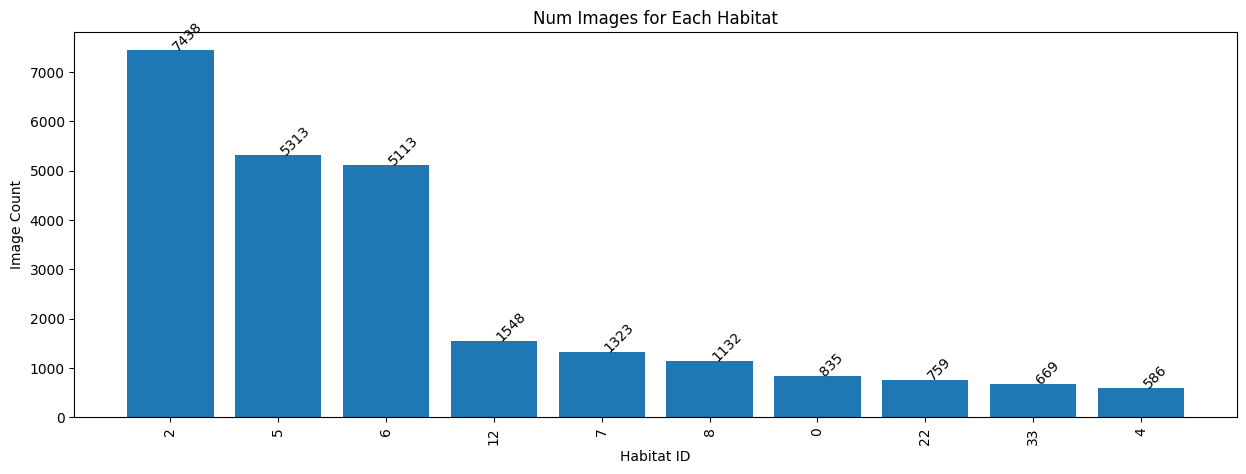

In [5]:
# Visualize
plt.figure(figsize=(15, 5))
plt.bar(range(len(list(sorted_by_values.keys()))), sorted_by_values.values())
plt.xlabel('Habitat ID')
plt.ylabel('Image Count')
plt.xticks(range(len(list(sorted_by_values.keys()))), labels=list(sorted_by_values.keys()), rotation=90)
plt.title('Num Images for Each Habitat')

for i, v in enumerate(sorted_by_values.values()):
    plt.text(i, v + 0.5, str(v), ha='left', rotation=45)


### No. of Fish Families in Each Habitat

In [6]:
# Get a dictionary mapping the number of families in the habitat with the respected habitat_id
hist = final_df[['Family', 'habitat_id']].groupby('habitat_id').nunique().to_dict()['Family']
# Sort the values for better visualization
sorted_by_values = dict(sorted(hist.items(), key=lambda item: item[1], reverse=True))

Statistical Analysis

In [7]:
values = list(sorted_by_values.values())
print(f'Max:\t {np.max(values)}')
print(f'Min:\t {np.min(values)}')
print(f'Mean:\t{np.mean(values): 0.2f}')
print(f'Median:\t{np.median(values): 0.2f}')

Max:	 89
Min:	 6
Mean:	 53.80
Median:	 49.00


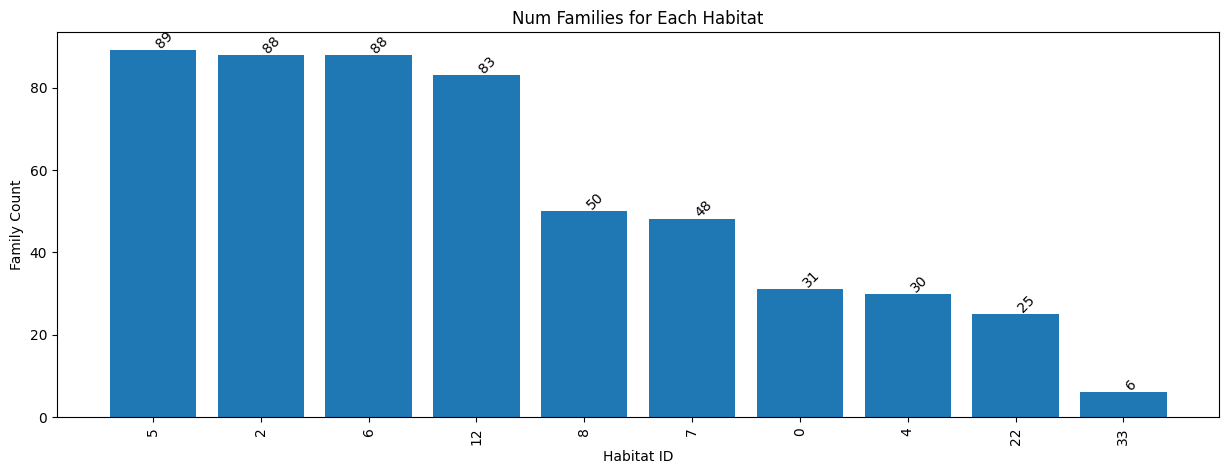

In [8]:
# Visualize
plt.figure(figsize=(15, 5))
plt.bar(range(len(list(sorted_by_values.keys()))), sorted_by_values.values())
plt.xlabel('Habitat ID')
plt.ylabel('Family Count')
plt.xticks(range(len(list(sorted_by_values.keys()))), labels=list(sorted_by_values.keys()), rotation=90)
plt.title('Num Families for Each Habitat')

for i, v in enumerate(sorted_by_values.values()):
    plt.text(i, v + 0.5, str(v), ha='left', rotation=45)

### No. of Fish Orders in Each Habitat

In [9]:
# Get a dictionary mapping the number of orders in the habitat with the respected habitat_id
hist = final_df[['Order', 'habitat_id']].groupby('habitat_id').nunique().to_dict()['Order']
# Sort the values for better visualization
sorted_by_values = dict(sorted(hist.items(), key=lambda item: item[1], reverse=True))

Statistical Analysis

In [10]:
values = list(sorted_by_values.values())
print(f'Max:\t {np.max(values)}')
print(f'Min:\t {np.min(values)}')
print(f'Mean:\t{np.mean(values): 0.2f}')
print(f'Median:\t{np.median(values): 0.2f}')

Max:	 20
Min:	 5
Mean:	 13.80
Median:	 15.00


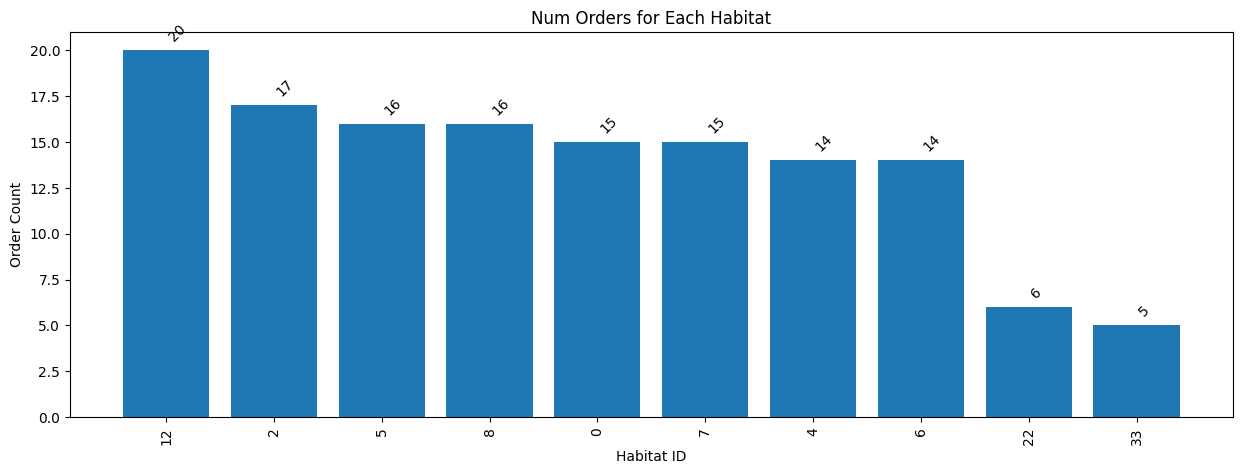

In [11]:
# Visualize
plt.figure(figsize=(15, 5))
plt.bar(range(len(list(sorted_by_values.keys()))), sorted_by_values.values())
plt.xlabel('Habitat ID')
plt.ylabel('Order Count')
plt.xticks(range(len(list(sorted_by_values.keys()))), labels=list(sorted_by_values.keys()), rotation=90)
plt.title('Num Orders for Each Habitat')

for i, v in enumerate(sorted_by_values.values()):
    plt.text(i, v + 0.5, str(v), ha='left', rotation=45)

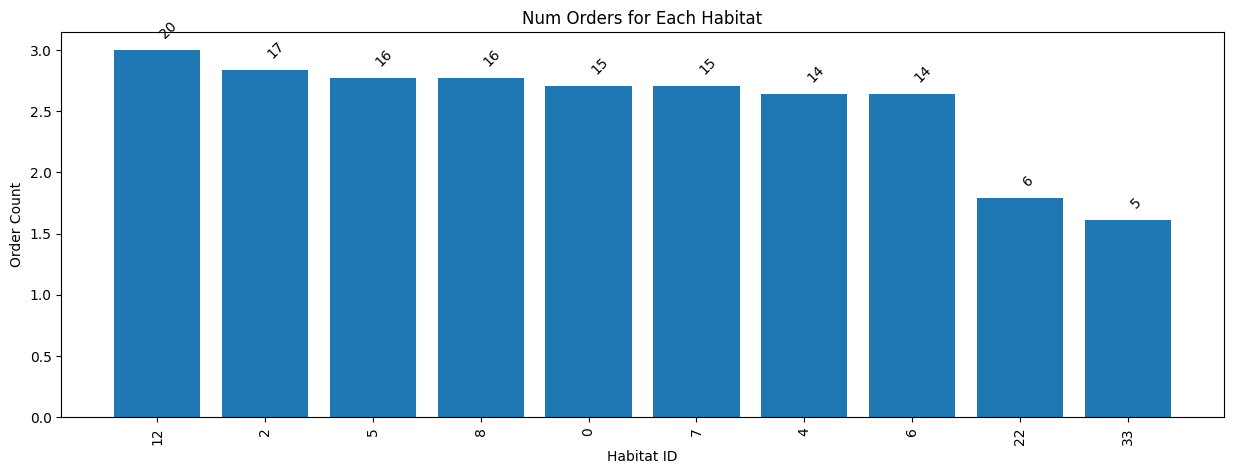

In [12]:
log_scale = np.log(list(sorted_by_values.values()))


plt.figure(figsize=(15, 5))
plt.bar(range(len(list(sorted_by_values.keys()))), log_scale)
plt.xlabel('Habitat ID')
plt.ylabel('Order Count')
plt.xticks(range(len(list(sorted_by_values.keys()))), labels=list(sorted_by_values.keys()), rotation=90)
plt.title('Num Orders for Each Habitat')

for i, (v, lv) in enumerate(zip(sorted_by_values.values(), log_scale)):
    plt.text(i, lv + 0.1, str(v), ha='left', rotation=45)

## Images per Familly

In [13]:
# Get a dictionary mapping the count of images in each family with the respected habitat_id
hist = final_df[['image', 'Family']].groupby('Family').agg('count').to_dict()['image']
# Sort the values for better visualization
sorted_by_values = dict(sorted(hist.items(), key=lambda item: item[1], reverse=True))

## Images per Order

In [14]:
# Get a dictionary mapping the count of images in each order with the respected habitat_id
hist = final_df[['image', 'Order']].groupby('Order').agg('count').to_dict()['image']
# Sort the values for better visualization
sorted_by_values = dict(sorted(hist.items(), key=lambda item: item[1], reverse=True))

Statistical Analysis

In [15]:
values = list(sorted_by_values.values())
print(f'Max:\t {np.max(values)}')
print(f'Min:\t {np.min(values)}')
print(f'Mean:\t{np.mean(values): 0.2f}')
print(f'Median:\t{np.median(values): 0.2f}')
print(f'Total Orders: {len(list(sorted_by_values.keys()))}')

Max:	 1500
Min:	 647
Mean:	 1235.80
Median:	 1336.00
Total Orders: 20


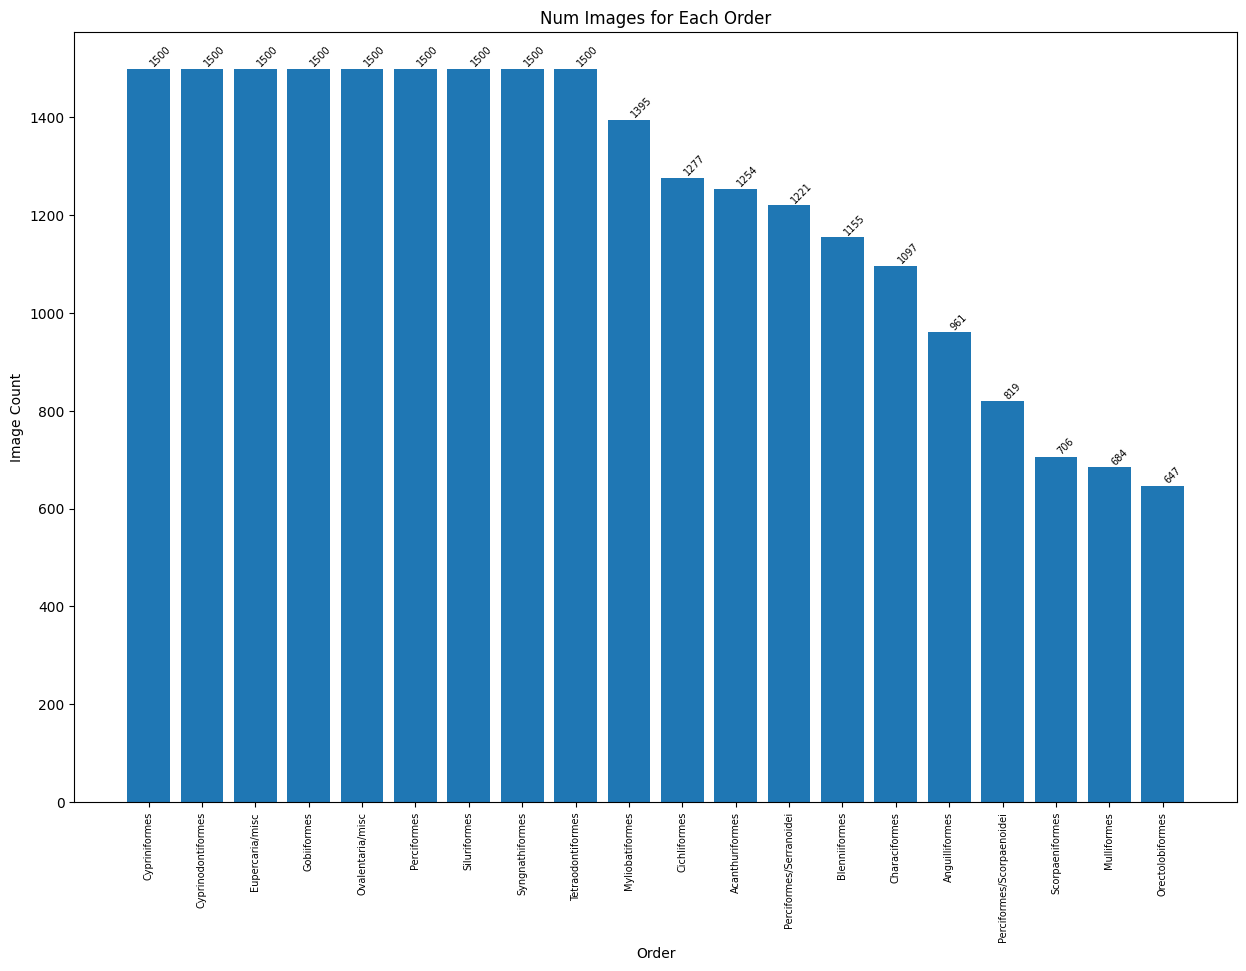

In [16]:
# Visualize
plt.figure(figsize=(15, 10))
plt.bar(range(len(hist)), sorted_by_values.values())
plt.xlabel('Order')
plt.ylabel('Image Count')
plt.xticks(range(len(hist)), labels=list(sorted_by_values.keys()), rotation=90, font={'size': 7})
plt.title('Num Images for Each Order')

for i, v in enumerate(sorted_by_values.values()):
    plt.text(i, v + 5, str(v), ha='left', rotation=45, font={'size': 7})